# Bonus — Aplicaciones de Machine Learning

Este notebook aborda tres problemas de ML con distintos enfoques:

1. **Clasificación de imágenes** — Detección de defectos en superficies metálicas industriales con una ResNet18 preentrenada.
2. **Predicción de mercado** — Predicción de retornos de la acción de Toyota con Random Forest.
3. **Riesgo crediticio** — Predicción de aprobación de préstamos con Regresión Logística.

Cada sección descarga su dataset desde Kaggle, realiza un análisis exploratorio, entrena un modelo y lo evalúa.


## Configuración

Instalación de dependencias externas e importación de todas las librerías utilizadas en el notebook.


In [1]:
%pip install -q kagglehub

In [2]:
import os
import glob

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    TimeSeriesSplit,
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    accuracy_score,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


## 1. Clasificación de imágenes — Defectos en superficies metálicas

Se ajusta una CNN (ResNet18 preentrenada en ImageNet) para clasificar imágenes de superficies metálicas en cinco categorías de defectos. El dataset se descarga desde Kaggle y contiene splits de entrenamiento y validación con imágenes en escala de grises.

### 1.1 Descarga del dataset


In [3]:
extract_path = kagglehub.dataset_download("tatheerabbas/synthetic-industrial-metal-surface-defects")
print("Ruta del dataset:", extract_path)

100%|██████████| 360M/360M [00:02<00:00, 184MB/s]

Extracting files...


Ruta del dataset: /root/.cache/kagglehub/datasets/tatheerabbas/synthetic-industrial-metal-surface-defects/versions/2


### 1.2 Carga y exploración de datos


In [4]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_path = os.path.join(extract_path, "industrial_defect_dataset", "train")
val_path = os.path.join(extract_path, "industrial_defect_dataset", "val")

train_dataset = datasets.ImageFolder(train_path, transform=transform)
val_dataset = datasets.ImageFolder(val_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("Clases:", train_dataset.classes)
print("Imágenes de entrenamiento:", len(train_dataset))
print("Imágenes de validación:", len(val_dataset))


Clases: ['crack', 'hole', 'normal', 'rust', 'scratch']
Imágenes de entrenamiento: 12000
Imágenes de validación: 3000


### 1.3 Entrenamiento básico de ResNet18

Se ajusta una ResNet18 preentrenada durante 5 épocas. La última capa fully-connected se reemplaza para producir 5 salidas correspondientes a las categorías de defectos.


In [5]:
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 5)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Época {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


Época 1, Loss: 0.0589
Época 2, Loss: 0.0475
Época 3, Loss: 0.0219
Época 4, Loss: 0.0124
Época 5, Loss: 0.0182


### 1.4 Entrenamiento con evaluación completa

El entrenamiento básico solo reporta el loss de entrenamiento. Para evaluar correctamente el rendimiento se reentrena un modelo nuevo y se registran accuracy de entrenamiento/validación, se genera un reporte de clasificación, matriz de confusión y curvas de aprendizaje.


Época 1/5
  Train Loss: 0.0666 | Train Acc: 0.9805
  Val Acc:    0.9543
----------------------------------------
Época 2/5
  Train Loss: 0.0167 | Train Acc: 0.9965
  Val Acc:    0.9980
----------------------------------------
Época 3/5
  Train Loss: 0.0235 | Train Acc: 0.9930
  Val Acc:    1.0000
----------------------------------------
Época 4/5
  Train Loss: 0.0056 | Train Acc: 0.9987
  Val Acc:    0.9990
----------------------------------------
Época 5/5
  Train Loss: 0.0345 | Train Acc: 0.9911
  Val Acc:    0.9990
----------------------------------------

Reporte de clasificación:

              precision    recall  f1-score   support

       crack       1.00      1.00      1.00       600
        hole       1.00      1.00      1.00       600
      normal       1.00      1.00      1.00       600
        rust       1.00      0.99      1.00       600
     scratch       1.00      1.00      1.00       600

    accuracy                           1.00      3000
   macro avg       1.00    

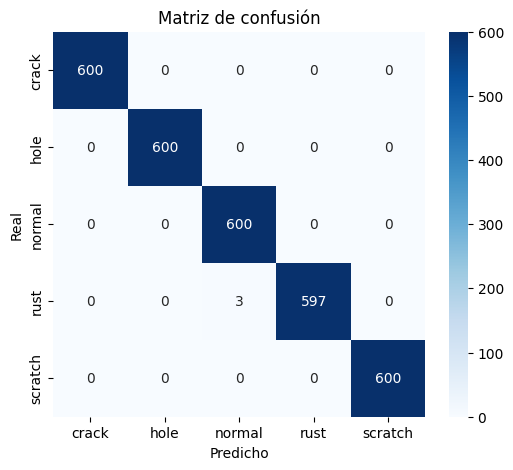

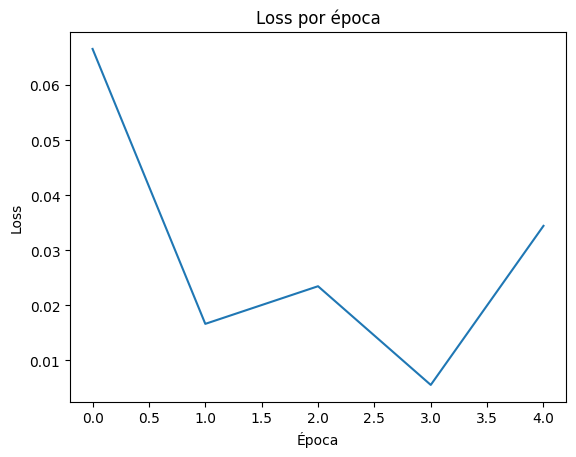

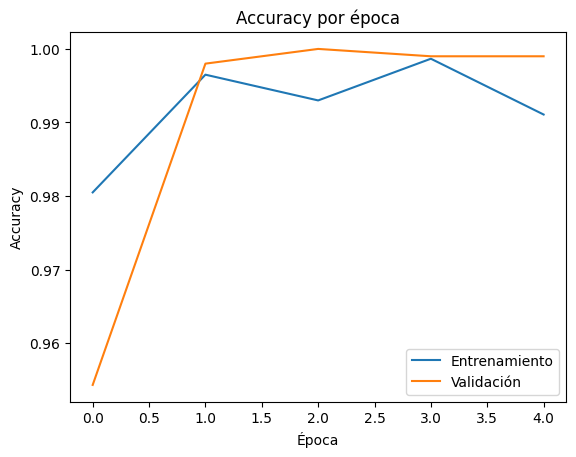

In [6]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 5)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
train_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f"Época {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Acc:    {val_acc:.4f}")
    print("-" * 40)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nReporte de clasificación:\n")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

plt.figure()
plt.plot(train_losses)
plt.title("Loss por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(train_accuracies, label="Entrenamiento")
plt.plot(val_accuracies, label="Validación")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### 1.5 Optimización de hiperparámetros (ResNet18)

Se realiza una búsqueda manual sobre la tasa de aprendizaje y el optimizador. Para cada combinación se entrena la red durante 5 épocas y se registra la accuracy de validación. Finalmente se compara el rendimiento de la configuración base contra la mejor configuración encontrada.


In [7]:
search_space = [
    {"lr": 0.001, "optimizer": "Adam"},
    {"lr": 0.0005, "optimizer": "Adam"},
    {"lr": 0.0001, "optimizer": "Adam"},
    {"lr": 0.001, "optimizer": "SGD"},
    {"lr": 0.01, "optimizer": "SGD"},
]

results = []

for config in search_space:
    model_hp = resnet18(weights=ResNet18_Weights.DEFAULT)
    model_hp.fc = nn.Linear(model_hp.fc.in_features, 5)
    model_hp = model_hp.to(device)

    if config["optimizer"] == "Adam":
        opt = optim.Adam(model_hp.parameters(), lr=config["lr"])
    else:
        opt = optim.SGD(model_hp.parameters(), lr=config["lr"], momentum=0.9)

    criterion_hp = nn.CrossEntropyLoss()

    for epoch in range(5):
        model_hp.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            opt.zero_grad()
            loss = criterion_hp(model_hp(images), labels)
            loss.backward()
            opt.step()

    model_hp.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_hp(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    results.append({**config, "val_acc": val_acc})
    print(f"Optimizer: {config['optimizer']}, LR: {config['lr']} -> Val Acc: {val_acc:.4f}")

results_df = pd.DataFrame(results).sort_values("val_acc", ascending=False)
print("\nResultados ordenados por accuracy de validación:\n")
print(results_df.to_string(index=False))

best = results_df.iloc[0]
baseline = next(r for r in results if r["lr"] == 0.001 and r["optimizer"] == "Adam")

print(f"\nConfiguración base (Adam, lr=0.001): Val Acc = {baseline['val_acc']:.4f}")
print(f"Mejor configuración ({best['optimizer']}, lr={best['lr']}): Val Acc = {best['val_acc']:.4f}")
print(f"Diferencia: {best['val_acc'] - baseline['val_acc']:+.4f}")


Optimizer: Adam, LR: 0.001 -> Val Acc: 1.0000
Optimizer: Adam, LR: 0.0005 -> Val Acc: 1.0000
Optimizer: Adam, LR: 0.0001 -> Val Acc: 0.9977
Optimizer: SGD, LR: 0.001 -> Val Acc: 0.9997
Optimizer: SGD, LR: 0.01 -> Val Acc: 1.0000

Resultados ordenados por accuracy de validación:

    lr optimizer  val_acc
0.0010      Adam 1.000000
0.0005      Adam 1.000000
0.0100       SGD 1.000000
0.0010       SGD 0.999667
0.0001      Adam 0.997667

Configuración base (Adam, lr=0.001): Val Acc = 1.0000
Mejor configuración (Adam, lr=0.001): Val Acc = 1.0000
Diferencia: +0.0000


## 2. Predicción de mercado — Acción de Toyota

Se utiliza un Random Forest para predecir el precio de cierre de la acción de Toyota a partir de las columnas Open, High, Low y Volume. El dataset abarca de 1980 a 2026.

### 2.1 Descarga del dataset


In [8]:
dataset_path = kagglehub.dataset_download("omarshahrukh/toyota-stock-prices-1980-2026-historical-data")
found = glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True)
toyota_csv = found[0]
print("Ruta del dataset:", toyota_csv)

100%|██████████| 168k/168k [00:00<00:00, 53.3MB/s]

Extracting files...
Ruta del dataset: /root/.cache/kagglehub/datasets/omarshahrukh/toyota-stock-prices-1980-2026-historical-data/versions/1/Toyota_Stock_Prices_1980_2026.csv


### 2.2 Exploración de datos


In [9]:
df_stock = pd.read_csv(toyota_csv)

print(df_stock.head())
print(df_stock.info())
print("Dimensiones:", df_stock.shape)

         Date   Close    High     Low    Open  Volume
0  1980-03-18  1.8207  1.8501  1.8207  1.8207    9343
1  1980-03-19  1.8207  1.8207  1.8207  1.8207       0
2  1980-03-20  1.8207  1.8501  1.8207  1.8207   10277
3  1980-03-21  1.8649  1.8944  1.8649  1.8649    8409
4  1980-03-24  1.8723  1.9017  1.8723  1.8723    2803
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11508 non-null  object 
 1   Close   11508 non-null  float64
 2   High    11508 non-null  float64
 3   Low     11508 non-null  float64
 4   Open    11508 non-null  float64
 5   Volume  11508 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 539.6+ KB
None
Dimensiones: (11508, 6)


### 2.3 Predicción del precio de cierre (Random Forest)

Primer enfoque: predecir directamente el precio de cierre (Close) a partir de las demás columnas. La división es secuencial (sin shuffle) para respetar el orden temporal.


Dimensiones: (11508, 6)
         Date   Close    High     Low    Open  Volume
0  1980-03-18  1.8207  1.8501  1.8207  1.8207    9343
1  1980-03-19  1.8207  1.8207  1.8207  1.8207       0
2  1980-03-20  1.8207  1.8501  1.8207  1.8207   10277
3  1980-03-21  1.8649  1.8944  1.8649  1.8649    8409
4  1980-03-24  1.8723  1.9017  1.8723  1.8723    2803

Métricas de regresión
  MAE:  34.7135
  MSE:  2437.7984
  RMSE: 49.3741
  R2:   -0.6981


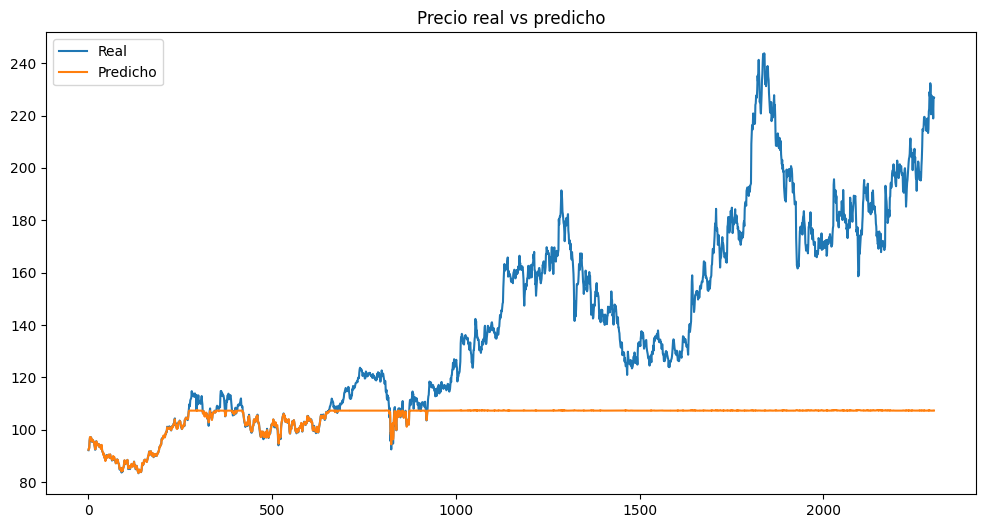

In [10]:
df = pd.read_csv(toyota_csv)

print("Dimensiones:", df.shape)
print(df.head())

X = df[["Open", "High", "Low", "Volume"]]
y = df["Close"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMétricas de regresión")
print(f"  MAE:  {mae:.4f}")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R2:   {r2:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred, label="Predicho")
plt.title("Precio real vs predicho")
plt.legend()
plt.show()


### 2.4 Predicción de retornos (Random Forest)

El modelo anterior se entrena con datos de los 80s y 90s pero se prueba con datos de 2010 a 2026, lo que genera que no prediga bien la escala del precio. Esto no es un problema del modelo sino del mercado: el precio absoluto cambia drásticamente en el tiempo.

La solución es predecir retornos porcentuales en lugar del precio en sí mismo, y luego extrapolar esos retornos al valor real de la acción.


Métricas de regresión
  MAE:  0.011406
  RMSE: 0.015882
  R2:   -0.143829


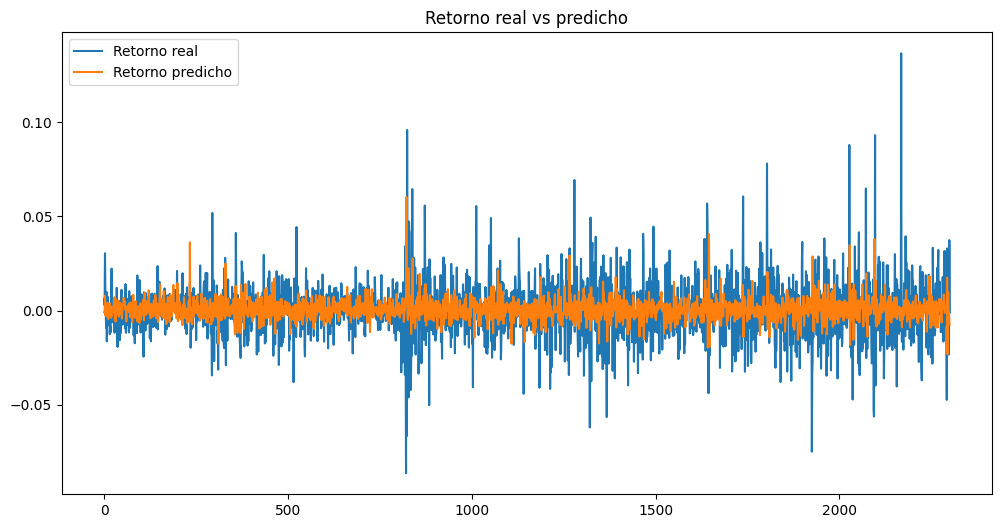

In [11]:
df = pd.read_csv(toyota_csv)

df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date", inplace=True)

df["Return"] = df["Close"].pct_change()
df["Return_lag1"] = df["Return"].shift(1)
df["Return_lag2"] = df["Return"].shift(2)
df["Return_lag3"] = df["Return"].shift(3)
df.dropna(inplace=True)

X = df[["Return_lag1", "Return_lag2", "Return_lag3"]]
y = df["Return"]

split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Métricas de regresión")
print(f"  MAE:  {mae:.6f}")
print(f"  RMSE: {rmse:.6f}")
print(f"  R2:   {r2:.6f}")

last_train_price = df["Close"].iloc[split_index]
predicted_prices = [last_train_price]
for r in y_pred:
    predicted_prices.append(predicted_prices[-1] * (1 + r))
predicted_prices = predicted_prices[1:]

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Retorno real")
plt.plot(y_pred, label="Retorno predicho")
plt.legend()
plt.title("Retorno real vs predicho")
plt.show()


### 2.5 Optimización de hiperparámetros (Random Forest)

Se aplica GridSearchCV con TimeSeriesSplit (3 folds) para buscar la mejor combinación de hiperparámetros del Random Forest. Los parámetros a optimizar son el número de árboles, la profundidad máxima y el mínimo de muestras por hoja. Se compara el rendimiento del modelo base contra el modelo optimizado usando MAE, RMSE y R2.


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Mejores hiperparámetros: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}

Comparación antes vs después del ajuste:

Métrica  Baseline  Optimizado  Diferencia
    MAE 34.713459   34.682901   -0.030558
   RMSE 49.374066   49.346603   -0.027464
     R2 -0.698121   -0.696233    0.001889


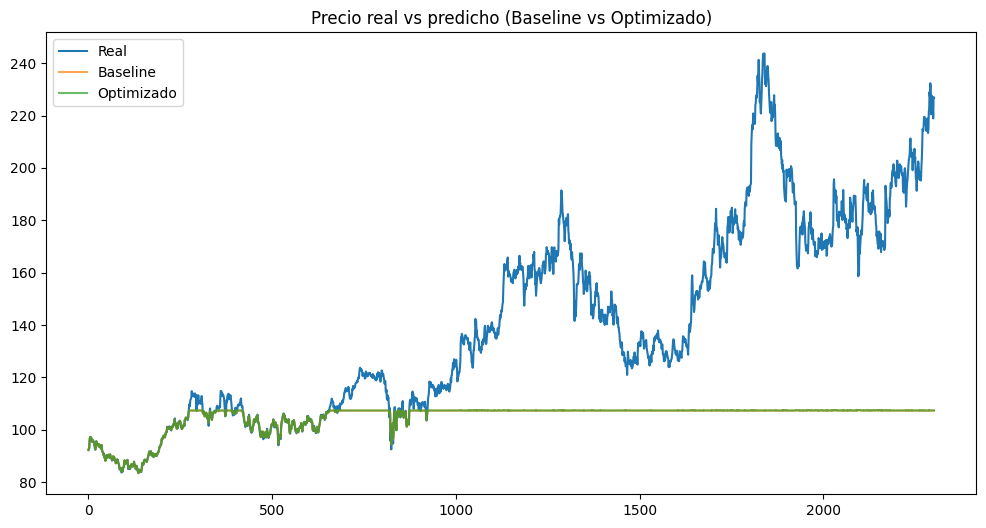

In [12]:
df_opt = pd.read_csv(toyota_csv)

X_opt = df_opt[["Open", "High", "Low", "Volume"]]
y_opt = df_opt["Close"]

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_opt, y_opt, test_size=0.2, shuffle=False
)

baseline_rf = RandomForestRegressor(n_estimators=200, random_state=42)
baseline_rf.fit(X_train_opt, y_train_opt)
y_pred_base = baseline_rf.predict(X_test_opt)

mae_base = mean_absolute_error(y_test_opt, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test_opt, y_pred_base))
r2_base = r2_score(y_test_opt, y_pred_base)

param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4],
}

tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train_opt, y_train_opt)

print("Mejores hiperparámetros:", grid_search.best_params_)

y_pred_tuned = grid_search.best_estimator_.predict(X_test_opt)

mae_tuned = mean_absolute_error(y_test_opt, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_opt, y_pred_tuned))
r2_tuned = r2_score(y_test_opt, y_pred_tuned)

comparison = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R2"],
    "Baseline": [mae_base, rmse_base, r2_base],
    "Optimizado": [mae_tuned, rmse_tuned, r2_tuned],
    "Diferencia": [mae_tuned - mae_base, rmse_tuned - rmse_base, r2_tuned - r2_base],
})
print("\nComparación antes vs después del ajuste:\n")
print(comparison.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.plot(y_test_opt.values, label="Real")
plt.plot(y_pred_base, label="Baseline", alpha=0.7)
plt.plot(y_pred_tuned, label="Optimizado", alpha=0.7)
plt.title("Precio real vs predicho (Baseline vs Optimizado)")
plt.legend()
plt.show()


# 2.6 Optimización de hiperparámetros (Random Forest) para retornos

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Mejores hiperparámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}

Comparación antes vs después del ajuste:

Métrica  Baseline  Optimizado  Diferencia
    MAE  0.011406    0.010556   -0.000850
   RMSE  0.015882    0.014931   -0.000951
     R2 -0.143829   -0.010992    0.132837


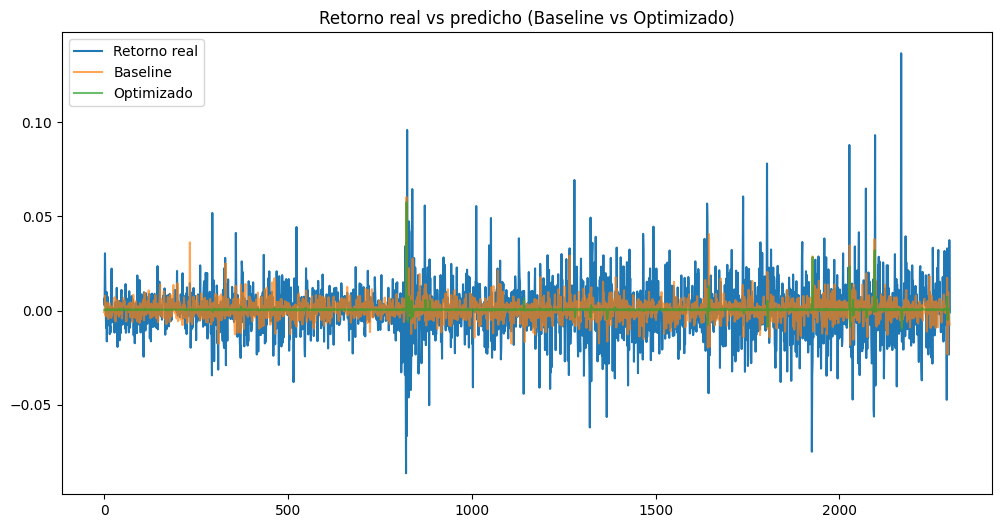

In [13]:

df = pd.read_csv(toyota_csv)

df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date", inplace=True)

df["Return"] = df["Close"].pct_change()
df["Return_lag1"] = df["Return"].shift(1)
df["Return_lag2"] = df["Return"].shift(2)
df["Return_lag3"] = df["Return"].shift(3)
df.dropna(inplace=True)

X = df[["Return_lag1", "Return_lag2", "Return_lag3"]]
y = df["Return"]

split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


baseline_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

baseline_rf.fit(X_train, y_train)
y_pred_base = baseline_rf.predict(X_test)

mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)



param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4],
}

tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)



best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)



comparison = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R2"],
    "Baseline": [mae_base, rmse_base, r2_base],
    "Optimizado": [mae_tuned, rmse_tuned, r2_tuned],
    "Diferencia": [
        mae_tuned - mae_base,
        rmse_tuned - rmse_base,
        r2_tuned - r2_base
    ],
})

print("\nComparación antes vs después del ajuste:\n")
print(comparison.to_string(index=False))



plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Retorno real")
plt.plot(y_pred_base, label="Baseline", alpha=0.7)
plt.plot(y_pred_tuned, label="Optimizado", alpha=0.7)
plt.legend()
plt.title("Retorno real vs predicho (Baseline vs Optimizado)")
plt.show()

## 3. Riesgo crediticio — Predicción de aprobación de préstamos

Se entrena un modelo de Regresión Logística para predecir si un préstamo será aprobado o rechazado. Se utiliza un pipeline de preprocesamiento que estandariza variables numéricas y codifica las categóricas con One-Hot Encoding.

### 3.1 Descarga del dataset


In [14]:
dataset_path = kagglehub.dataset_download("sohailkhan05/loan-risk-prediction")
found = glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True)
loan_csv = found[0]
print("Ruta del dataset:", loan_csv)

100%|██████████| 73.0k/73.0k [00:00<00:00, 44.0MB/s]

Extracting files...
Ruta del dataset: /root/.cache/kagglehub/datasets/sohailkhan05/loan-risk-prediction/versions/1/loan_risk_prediction_dataset.csv


### 3.2 Exploración de datos


In [15]:
df_loan = pd.read_csv(loan_csv)

print(df_loan.head())
print(df_loan.info())
print("Dimensiones:", df_loan.shape)

   Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  \
0   56  48353.0     31258.0        675.0               20  Female   
1   69  57462.0     23262.0        586.0                6    Male   
2   46  44219.0     26530.0        781.0               26    Male   
3   32  56307.0     11531.0        549.0               11    Male   
4   60  37034.0     27871.0        500.0               19  Female   

     Education           City EmploymentType  LoanApproved  
0  High School        Houston     Unemployed             0  
1  High School  San Francisco  Self-Employed             0  
2          PhD        Houston  Self-Employed             1  
3          NaN       New York     Unemployed             0  
4  High School        Chicago     Unemployed             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age            

### 3.3 Entrenamiento y evaluación (Regresión Logística)

Se construye un pipeline que estandariza las variables numéricas y codifica las categóricas. Se utiliza Regresión Logística con pesos balanceados para compensar posibles desbalances de clase.


In [16]:
df = pd.read_csv(loan_csv)

print("Dimensiones:", df.shape)
print(df.head())

df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna("Unknown", inplace=True)

X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Dimensiones: (5000, 10)
   Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  \
0   56  48353.0     31258.0        675.0               20  Female   
1   69  57462.0     23262.0        586.0                6    Male   
2   46  44219.0     26530.0        781.0               26    Male   
3   32  56307.0     11531.0        549.0               11    Male   
4   60  37034.0     27871.0        500.0               19  Female   

     Education           City EmploymentType  LoanApproved  
0  High School        Houston     Unemployed             0  
1  High School  San Francisco  Self-Employed             0  
2          PhD        Houston  Self-Employed             1  
3          NaN       New York     Unemployed             0  
4  High School        Chicago     Unemployed             0  

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       775
           1       0.64      0.90      0.75       225

    

### 3.4 Optimización de hiperparámetros (Regresión Logística)

Se aplica GridSearchCV con 5 folds para optimizar el parámetro de regularización C y el tipo de penalización de la Regresión Logística. Se compara el rendimiento del modelo base contra el optimizado usando accuracy, precisión, recall y F1-score.


In [17]:
df_lr = pd.read_csv(loan_csv)

df_lr.fillna(df_lr.mean(numeric_only=True), inplace=True)
df_lr.fillna("Unknown", inplace=True)

X_lr = df_lr.drop("LoanApproved", axis=1)
y_lr = df_lr["LoanApproved"]

num_cols_lr = X_lr.select_dtypes(include=["int64", "float64"]).columns
cat_cols_lr = X_lr.select_dtypes(include=["object"]).columns

preprocessor_lr = ColumnTransformer([
    ("num", StandardScaler(), num_cols_lr),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_lr)
])

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

baseline_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=42
    ))
])
baseline_pipe.fit(X_train_lr, y_train_lr)
y_pred_base_lr = baseline_pipe.predict(X_test_lr)
acc_base = accuracy_score(y_test_lr, y_pred_base_lr)

param_grid_lr = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear", "saga"],
}

grid_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=42
    ))
])

grid_lr = GridSearchCV(
    grid_pipe,
    param_grid_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_lr.fit(X_train_lr, y_train_lr)

print("Mejores hiperparámetros:", grid_lr.best_params_)

y_pred_tuned_lr = grid_lr.best_estimator_.predict(X_test_lr)
acc_tuned = accuracy_score(y_test_lr, y_pred_tuned_lr)

print(f"\nAccuracy base (C=1, l2):     {acc_base:.4f}")
print(f"Accuracy optimizado:         {acc_tuned:.4f}")
print(f"Diferencia:                  {acc_tuned - acc_base:+.4f}")

print("\n--- Reporte base ---")
print(classification_report(y_test_lr, y_pred_base_lr))

print("--- Reporte optimizado ---")
print(classification_report(y_test_lr, y_pred_tuned_lr))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores hiperparámetros: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}

Accuracy base (C=1, l2):     0.8620
Accuracy optimizado:         0.8680
Diferencia:                  +0.0060

--- Reporte base ---
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       775
           1       0.64      0.90      0.75       225

    accuracy                           0.86      1000
   macro avg       0.80      0.88      0.83      1000
weighted avg       0.89      0.86      0.87      1000

--- Reporte optimizado ---
              precision    recall  f1-score   support

           0       0.97      0.86      0.91       775
           1       0.65      0.91      0.76       225

    accuracy                           0.87      1000
   macro avg       0.81      0.88      0.83      1000
weighted avg       0.90      0.87      0.88      1000



# 4. Análisis y conclusiones

En esta actividad se aplicó *tuning* de hiperparámetros (búsqueda en malla / búsqueda manual) y se comparó el desempeño antes vs después con métricas apropiadas. En el caso de mercado, se priorizó predecir el retorno porcentual diario (ganancia/pérdida relativa) sobre el precio absoluto, ya que el mercado es no estacionario y la escala del precio cambia con el tiempo.

## 4.1 Resumen cuantitativo (antes vs después)

| Caso | Modelo | Métrica(s) | Baseline | Optimizado | Cambio |
|---|---|---:|---:|---:|---:|
| 1) Defectos metálicos | ResNet18 (transfer learning) | Val Accuracy | 1.0000 | 1.0000 | +0.0000 |
| 2) Toyota (precio absoluto) | Random Forest Regressor | MAE / RMSE / R² | 34.7135 / 49.3741 / -0.6981 | 34.6829 / 49.3466 / -0.6962 | -0.0306 / -0.0275 / +0.0019 |
| 2) Toyota (retorno diario) | Random Forest Regressor | MAE / RMSE / R² | 0.011406 / 0.015882 / -0.143829 | 0.010556 / 0.014931 / -0.010992 | -0.000850 / -0.000951 / +0.132837 |
| 3) Riesgo crediticio | Regresión Logística (pipeline) | Accuracy | 0.8620 | 0.8680 | +0.0060 |

Notas:
- En retornos, los valores están en escala decimal: p.ej. MAE=0.0106 equivale a un error absoluto medio de ~1.06% por día.
- En R², valores negativos indican que el modelo explica menos variabilidad que un predictor ingenuo que usa la media del conjunto de entrenamiento.

## 4.2 Caso 1 — Clasificación de defectos (ResNet18)

**Qué pasó antes del tuning**
- El entrenamiento con ResNet18 preentrenada alcanzó rápidamente accuracies muy altas: el *Val Acc* llega a ~0.998–1.000 en pocas épocas, y el reporte de clasificación muestra métricas cercanas a 1.00 en todas las clases.
- La matriz de confusión indica errores muy puntuales (por ejemplo, confusiones aisladas entre `rust` y `normal`), lo que sugiere que el problema es relativamente “fácil” para este modelo con *transfer learning* y el preprocesamiento usado.

**Impacto del tuning**
- La búsqueda manual sobre `lr` y optimizador (Adam/SGD) no mejoró la *Val Accuracy* respecto a la configuración base (+0.0000).
- Interpretación: esto es un efecto techo. Cuando el desempeño ya está prácticamente saturado (cerca de 100%), pequeñas variaciones de hiperparámetros no se reflejan en la métrica agregada.

**Conclusión**
- En este dataset, el tuning de hiperparámetros **no** aporta una mejora medible porque el modelo base ya alcanza rendimiento casi perfecto. La lección principal es que el tuning tiene retornos decrecientes cuando la métrica está en el límite superior.

## 4.3 Caso 2 — Predicción de mercado (Toyota) con Random Forest

### (a) Predicción de precio absoluto (`Close`)

**Qué pasó antes del tuning**
- Las métricas del baseline son pobres, con R² fuertemente negativo (≈ -0.698), lo que indica que el modelo no logra capturar la dinámica del precio en el periodo de prueba.
- Visualmente, la predicción tiende a quedarse “pegada” a rangos típicos del entrenamiento, y no sigue la tendencia de largo plazo del precio.

**Impacto del tuning**
- El GridSearchCV logra una mejora muy marginal: MAE y RMSE bajan apenas, y R² sube ~0.0019 (sigue siendo negativo).
- Interpretación: ajustar hiperparámetros no resuelve el problema estructural de intentar predecir precios absolutos en un mercado no estacionario, además de la limitación del Random Forest para extrapolar fuera del rango aprendido.

### (b) Predicción de retorno porcentual diario (`Return`) 

**Por qué este target es más adecuado**
- Al usar `pct_change()` se normaliza la escala y se modela una cantidad más comparable a través del tiempo: cuánto puede subir o bajar una acción en un día (en %).
- Esto reduce (aunque no elimina) el impacto de cambios de régimen y de la tendencia de largo plazo del precio.

**Qué pasó antes del tuning**
- El baseline obtiene MAE ≈ 0.0114 (≈ 1.14%) y RMSE ≈ 0.0159 (≈ 1.59%), con R² ≈ -0.144. Es decir: el error promedio es relativamente bajo porque la mayoría de retornos diarios son pequeños, pero el modelo explica poca varianza.

**Impacto del tuning**
- Con `max_depth=10`, `n_estimators=200`, `min_samples_leaf=1`, el modelo mejora de forma consistente:
  - MAE baja de ~1.14% a ~1.06%
  - RMSE baja de ~1.59% a ~1.49%
  - R² sube de -0.144 a -0.011 (mucho más cerca de 0)
- Interpretación: el tuning sí ayuda a regularizar la complejidad (profundidad) y a estabilizar el ensamble, reduciendo error y acercándose a un desempeño similar al predictor de media. Sin embargo, el R² aún no es positivo, lo que es coherente con que los retornos diarios se aproximan a un proceso de baja predictibilidad con pocas variables rezagadas.

**Conclusión**
- Cambiar el objetivo a retornos porcentuales fue más importante que el tuning: mejora la formulación del problema para un mercado no estacionario.
- El tuning mejora métricas de forma clara en retornos, pero el límite viene dado por el bajo contenido de señal del set de features (solo lags de retorno) y la naturaleza ruidosa del mercado.

## 4.4 Caso 3 — Riesgo crediticio (Regresión Logística)

**Qué pasó antes del tuning**
- El pipeline baseline logra accuracy = 0.862. En el reporte, la clase positiva (aprobado = 1) muestra *recall* alto (~0.90), a costa de una precisión moderada (~0.64), lo que es común cuando se prioriza capturar positivos y se usan `class_weight='balanced'`.
- Este comportamiento es razonable en riesgo crediticio cuando el costo de falsos negativos puede ser alto (depende del criterio del negocio).

**Impacto del tuning**
- El GridSearchCV encuentra una configuración con `penalty='l1'` y `C=0.1` (regularización más fuerte, con selección implícita de variables).
- El desempeño mejora ligeramente: accuracy sube a 0.868 (+0.006) y también se observa una mejora pequeña en la clase positiva (p.ej. precisión ~0.65 y recall ~0.91).
- Interpretación: el tuning ayuda a controlar sobreajuste y a manejar mejor la alta dimensionalidad derivada del One-Hot Encoding.

**Conclusión**
- El tuning aporta una mejora incremental pero consistente, especialmente relevante cuando se busca un equilibrio fino entre precisión/recall en un problema con posibles desbalances y costos asimétricos.

## 4.5 Conclusiones finales (los 3 casos)

- El impacto del tuning depende del punto de partida: cuando el baseline ya está al límite, el beneficio marginal puede ser insignificante.
- En datos no estacionarios como mercado, formular bien el target puede tener más impacto que ajustar hiperparámetros sobre el precio absoluto.
- En modelos tabulares con alta dimensionalidad, el tuning de regularización puede aportar mejoras pequeñas pero útiles, mejorando generalización y estabilidad.